<a href="https://colab.research.google.com/github/Arnav007-python/Unemployment_Analysis_using_Python/blob/main/CodeAlpha__Unemployment_Analysis_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- Both Files Loaded Successfully ---
File 1 (Historical/Area Split) Shape: (768, 7)
File 2 (Regional/Coordinates) Shape: (267, 9)

--- Cleaning & Preprocessing Datasets ---
Columns unified and space padding stripped.

--- Combining Datasets ---
Unified Timeline Created. Total rows: 1007

--- Running COVID-19 Impact Analytics ---
Mean Pre-Pandemic Unemployment: 9.48%
Mean Core Pandemic Lockdown Unemployment: 15.81%


/tmp/ipykernel_710/57159408.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x='Area', y='Unemployment_Rate', palette='Set2')
/tmp/ipykernel_710/57159408.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_impacted, x='Unemployment_Rate', y='Region', palette='viridis')


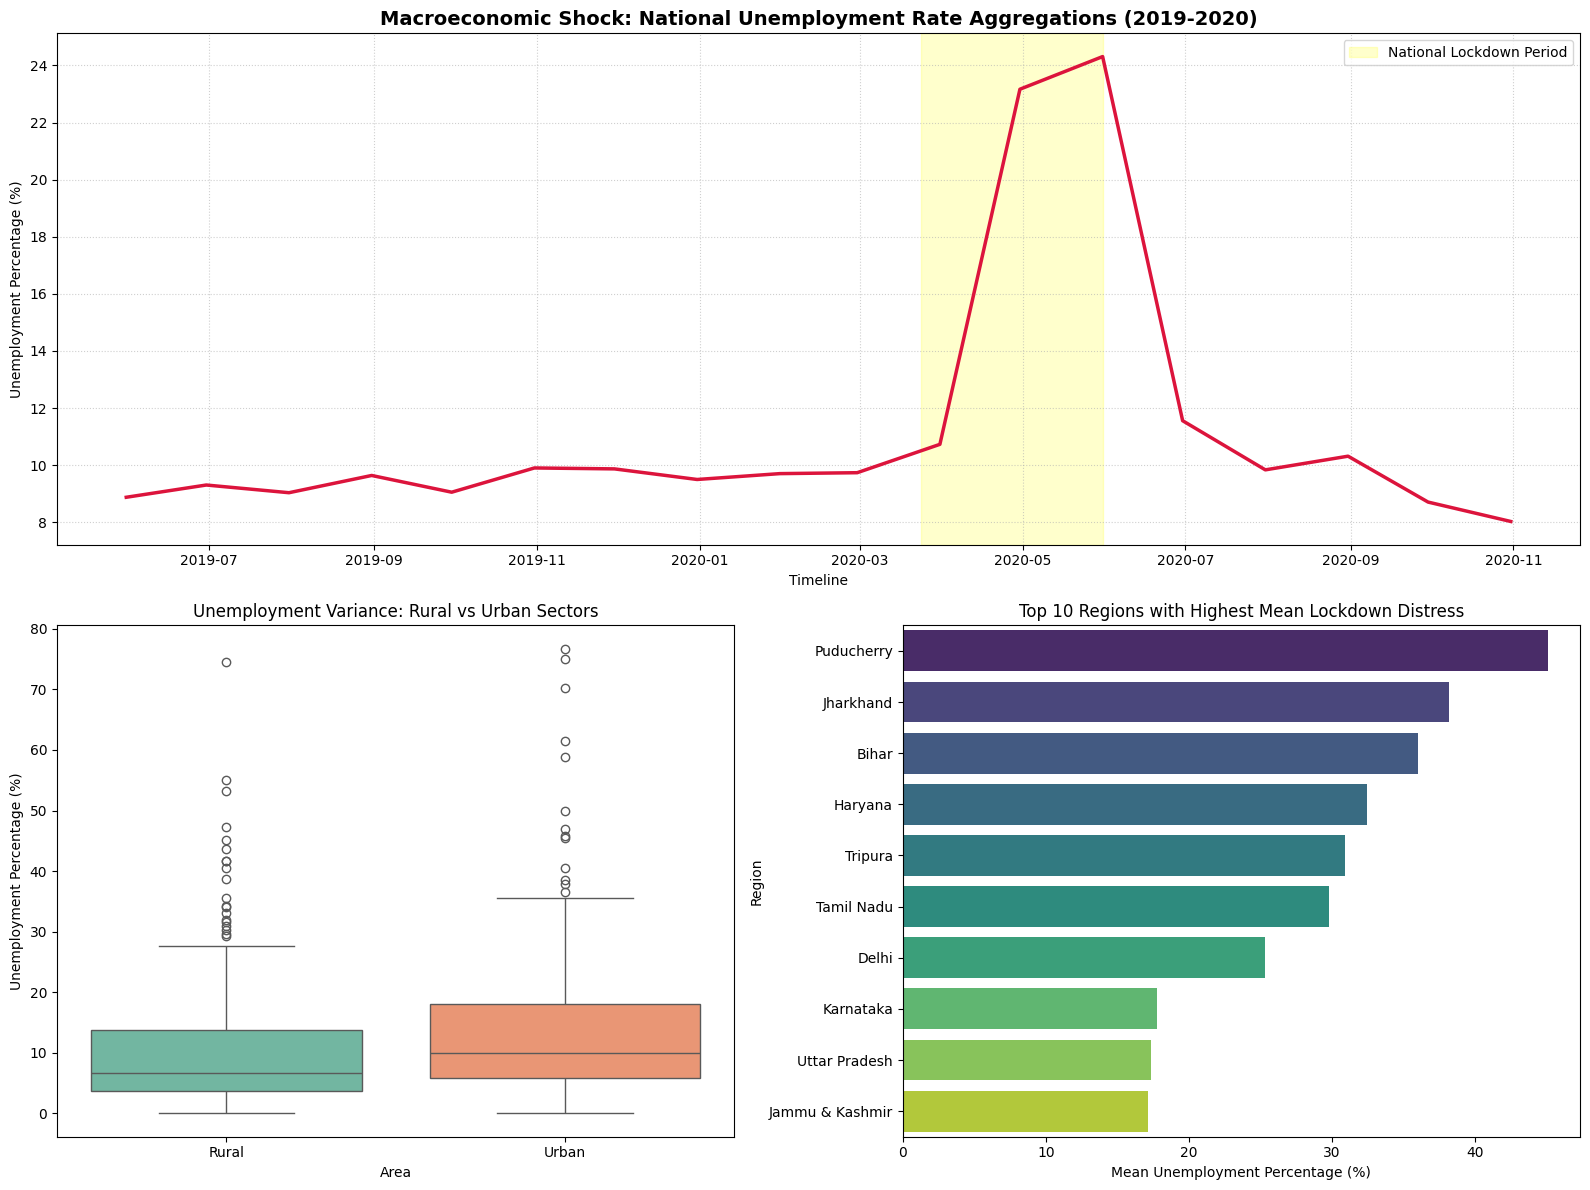

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Mount your Google Drive
drive.mount('/content/drive')

# 2. Define filenames (Assumes they are saved directly in your My Drive)
file1_path = '/content/drive/MyDrive/CodeA/Unemployment in India.csv'
file2_path = '/content/drive/MyDrive/CodeA/Unemployment_Rate_upto_11_2020.csv'

try:
    df1 = pd.read_csv(file1_path)
    df2 = pd.read_csv(file2_path)
    print("--- Both Files Loaded Successfully ---")
    print(f"File 1 (Historical/Area Split) Shape: {df1.shape}")
    print(f"File 2 (Regional/Coordinates) Shape: {df2.shape}")
except FileNotFoundError as e:
    print(f"Error loading files. Verify paths or spelling. Details: {e}")

print("\n--- Cleaning & Preprocessing Datasets ---")

# These datasets are notorious for hidden leading/trailing spaces in column headers
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

# Drop rows where vital elements are entirely blank/NaN (File 1 has trailing blank records)
df1 = df1.dropna(subset=['Region', 'Date'])
df2 = df2.dropna(subset=['Region', 'Date'])

# Standardize Date column formats into real datetime objects
df1['Date'] = pd.to_datetime(df1['Date'].str.strip(), dayfirst=True, errors='coerce')
df2['Date'] = pd.to_datetime(df2['Date'].str.strip(), dayfirst=True, errors='coerce')

# Rename metric columns to matching names across both sources
rename_dict = {
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}
df1.rename(columns=rename_dict, inplace=True)
df2.rename(columns=rename_dict, inplace=True)

print("Columns unified and space padding stripped.")

print("\n--- Combining Datasets ---")


combined_timeline = pd.concat([df1[['Region', 'Date', 'Unemployment_Rate', 'Employed']],
                               df2[['Region', 'Date', 'Unemployment_Rate', 'Employed']]],
                              ignore_index=True).drop_duplicates()

# Sort records Chronologically
combined_timeline = combined_timeline.sort_values('Date')

# Extract baseline time configurations
combined_timeline['Year'] = combined_timeline['Date'].dt.year
combined_timeline['Month'] = combined_timeline['Date'].dt.month

print(f"Unified Timeline Created. Total rows: {combined_timeline.shape[0]}")

print("\n--- Running COVID-19 Impact Analytics ---")

# Isolate pre-shock vs post-shock phases (Pre-March 2020 vs Lockdowns)
pre_covid = combined_timeline[combined_timeline['Date'] < '2020-03-01']
post_covid_lockdowns = combined_timeline[(combined_timeline['Date'] >= '2020-03-01') & (combined_timeline['Date'] <= '2020-10-01')]

print(f"Mean Pre-Pandemic Unemployment: {pre_covid['Unemployment_Rate'].mean():.2f}%")
print(f"Mean Core Pandemic Lockdown Unemployment: {post_covid_lockdowns['Unemployment_Rate'].mean():.2f}%")

plt.figure(figsize=(16, 12))

# Subplot 1: Macro Timeline Spike Analysis (Combined Data)
plt.subplot(2, 1, 1)
sns.lineplot(data=combined_timeline, x='Date', y='Unemployment_Rate', color='crimson', errorbar=None, lw=2.5)
plt.axvspan('2020-03-24', '2020-05-31', color='yellow', alpha=0.2, label='National Lockdown Period')
plt.title('Macroeconomic Shock: National Unemployment Rate Aggregations (2019-2020)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline')
plt.ylabel('Unemployment Percentage (%)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Structural Differences: Rural vs Urban (Using File 1 Specific Context)
plt.subplot(2, 2, 3)
sns.boxplot(data=df1, x='Area', y='Unemployment_Rate', palette='Set2')
plt.title('Unemployment Variance: Rural vs Urban Sectors', fontsize=12)
plt.ylabel('Unemployment Percentage (%)')

# Subplot 3: Regional Disparities: Top Impacted States during Lockdown (Using File 2 Coordinates/Regions)
plt.subplot(2, 2, 4)
lockdown_states = df2[df2['Date'].between('2020-03-01', '2020-06-01')]
top_impacted = lockdown_states.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).head(10).reset_index()

sns.barplot(data=top_impacted, x='Unemployment_Rate', y='Region', palette='viridis')
plt.title('Top 10 Regions with Highest Mean Lockdown Distress', fontsize=12)
plt.xlabel('Mean Unemployment Percentage (%)')

plt.tight_layout()
plt.show()